In [2]:
import scipy
import numpy as np
# import tensorflow as tf
# from tensorflow import keras
import time
import sys
import csv

from io import UnsupportedOperation
import pickle as pkl

import matplotlib.pyplot as plt
import seaborn as sns


# Add shared location for auxillary functions
sys.path.insert(1, './../../AuxillaryFunctions')


# import personal Functions
from GenerateClassDataFuncs import GenerateEvalData_ClemCafe
from GenerateClassDataFuncs import GenerateEvalData_OREBA
from GenerateClassDataFuncs import GenerateTallyCounts


from DetectionPlacementFuncs import Cnt2Detect_MidpointTriggerMidpointPlacement
from DetectionPlacementFuncs import Cnt2Detect_TetrisBlockFilling
from DetectionPlacementFuncs import Cnt2Detect_TemplateMatching
from DetectionPlacementFuncs import Cnt2Detect_TetrisBlockFilling_Midpt

# from Scaled_GenerateClassDataFuncs import Scaled_GenerateDataAndClasses_ClemCafe_WinCnt
# from Scaled_GenerateClassDataFuncs import Scaled_GenerateDataAndClasses_OREBA_WinCnt

print("Finished Importing Modules.")

Finished Importing Modules.


In [3]:
def readPredCSV(fileName):
	with open(fileName, mode ='r') as fp:
		csvFile = csv.reader(fp)
		Predictions = []
		Timesteps = []
		for row in csvFile:
			Predictions.append(float(row[0]))
			Timesteps.append(float(row[1]))
		# end
		# print(len(Predictions))
	# end of open fp
	
	return [Predictions, Timesteps]
# end of def()


def readGtCSV(fileName):
	with open(fileName, mode ='r') as fp:
		csvFile = csv.reader(fp)
		GT_events = []
		for row in csvFile:
			GT_events.append(float(row[0]))
		# end
		# print(len(GT_events))
	# end of open fp

	return GT_events
# end of def()


print("Finished defining local functions.")


Finished defining local functions.


In [100]:
# Loop over all Files Meals
# ClemsonPredFileList =  [line[:-1] for line in open("Predictions/ClemPredFiles.txt",'r')]
# ClemsonGTFileList =  [line[:-1] for line in open("Predictions/ClemGtFiles.txt",'r')]
# OHOPredFileList =  [line[:-1] for line in open("Predictions/OHOPredFiles.txt",'r')]
# OHOGTFileList =  [line[:-1] for line in open("Predictions/OHOGtFiles.txt",'r')]
# THOPredFileList =  [line[:-1] for line in open("Predictions/THOPredFiles.txt",'r')]
# THOGTFileList =  [line[:-1] for line in open("Predictions/THOGtFiles.txt",'r')]


DATABASE_FLAG = 2
	# 1 = OHO
	# 2 = THO
	# 3 = Clem

DATA_SELECT_FLAG = 16
	# 1 = 40 sec OHO
	# 2 = 25 sec OHO
	# 3 = Paper A1333 OHO
	# 4 = Paper A1333 THO
	# 5 = Paper A1333 Clem
	# 6 = Paper GRU THO
	# 7 = Paper GRUc3 THO
	# 8 = Paper GRUc5 THO
	# 9 = Paper GRUv101 THO
	# 10 = Paper GRUv101 THO
	# 11 = Paper GRU Dr103 THO
	# 12 = Paper GRU NoMHA THO
	# 13 = Paper GRU NoGRU THO
	# 14 = Paper GRU OneGRU THO
	# 15 = Paper GRU TwoGRU THO
	# 16 = Paper GRU THO
	# Else = invalid

currMealNum = 28



if DATA_SELECT_FLAG == 1:
	WINDOW_SIZE = 40
	OHO_Pred_Filelist =  ['./../LayerSearch_TallyNet/Predictions/OHO_W40_A1343_s10_0_Pred_MN0{:02d}.csv'.format(currMealNum)]
elif DATA_SELECT_FLAG == 2:
	WINDOW_SIZE = 25
	OHO_Pred_Filelist =  ['./../LayerSearch_TallyNet/Predictions/OHO_W25_A1343_s10_0_Pred_MN0{:02d}.csv'.format(currMealNum)]
elif DATA_SELECT_FLAG == 3:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_1_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_2_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_s03_4_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_s03_5_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_s03_6_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_s05_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_s03_6_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/OHO_Preds/OHO_A1333_s05_0_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 4:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		# '/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		# '/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_1_Pred_MN0{:02d}.csv'.format(currMealNum),
		# '/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_2_Pred_MN0{:02d}.csv'.format(currMealNum),
		# '/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s02_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s03_2_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s03_3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s03_4_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s03_5_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s03_6_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s05_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/THO_Preds/THO_A1333_s05_1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 5:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_1_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_2_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_0_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_1_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_2_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_4_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_5_Pred_MN0{:02d}.csv'.format(currMealNum),
		'/scratch/jpjolly/TallyNetPreds/Clem_Preds/Clem_A1333_s05_6_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 6:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRU_Run1_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/GRU/THO_TN_GRU_Run2_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/GRU/THO_TN_GRU_Run3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/GRU/THO_TN_GRU_Run4_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/GRU/THO_TN_GRU_Run5_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/GRU/THO_TN_GRU_Run6_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 7:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRUc3_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 8:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRUc5_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 9:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRUv101_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 10:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRUlnv1_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 11:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRU_1Dr03_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 12:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRU_NoMHA_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 13:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRU_NoGRU_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 14:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRU_OneGRU_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 15:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/GRU/THO_TN_GRU_TwoGRU_Run1_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
elif DATA_SELECT_FLAG == 16:
    WINDOW_SIZE = 15
    OHO_Pred_Filelist =  [
		'./../Predictions/CGv3/THO_TN_CGv3_Run1_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/CGv3/THO_TN_CGv3_Run2_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/CGv3/THO_TN_CGv3_Run3_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/CGv3/THO_TN_CGv3_Run4_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/CGv3/THO_TN_CGv3_Run5_Pred_MN0{:02d}.csv'.format(currMealNum),
		'./../Predictions/CGv3/THO_TN_CGv3_Run6_Pred_MN0{:02d}.csv'.format(currMealNum)
	]
else:
	raise "INVALID DATA_SELECT_FLAG Selected"
# end



if DATABASE_FLAG == 1 or DATABASE_FLAG == 2: # Grab OREBA GT Data (Same for both OHO and THO) 
	DATABASE_FILEPATH = "./../../Pickle_Databases/Dnd_TwoHandOreba.pkl"
	with open(DATABASE_FILEPATH,'rb') as fh:
		dataset = pkl.load(fh)
	#OREBA_Cucumber={'UniqueID','proc_data','handedness','bites_gt'}
	OrigFreq = 64 # [Hz] Oreba data collection rate

	# proc = dataset['proc_data']
	biteGT_times=dataset['bites_gt']
	handednessList = dataset['handedness']
	# gt_handed_labels = dataset['bites_handedness_gt']
	uniqueIDs = dataset['UniqueID']
	
elif DATABASE_FLAG == 3: # Grab Clemson Data for GTs
	DATABASE_FILEPATH = "./../../Pickle_Databases/Dnd_Clemson.pkl"
	with open(DATABASE_FILEPATH,'rb') as fh:
		dataset = pkl.load(fh)
	#OREBA_Cucumber={'UniqueID','proc_data','handedness','bites_gt'}
	OrigFreq = 64 # [Hz] Oreba data collection rate

	# proc = dataset['proc_data']
	biteGT_times=dataset['bites_gt']
	handednessList = dataset['handedness']
	# gt_handed_labels = dataset['bites_handedness_gt']
	uniqueIDs = dataset['UniqueID']
# end of DATABASE_FLAG SWITCH
print("Finished Loading Data Files")

Finished Loading Data Files


In [101]:
### OHO STATS ###

AllDiffs = []
AllPreds = []
AllTimesteps = []
AllCounts = []

for currFileIdx in range(len(OHO_Pred_Filelist)):

	[preds, timesteps] = readPredCSV(OHO_Pred_Filelist[currFileIdx])
	# gt_times = np.array(readGtCSV(OHOGTFileList[currFileIdx]))
	gt_times = (biteGT_times[currMealNum][:,0] + biteGT_times[currMealNum][:,1])/2
	gt_times_wind = biteGT_times[currMealNum]

	CUT_sec = WINDOW_SIZE # 15 second models
	Counts = GenerateTallyCounts(gt_times, timesteps, CUT_sec)

	currDiffs = []
	for i in range(len(preds)):
		currDiffs.append(preds[i] - Counts[i])
	# end of j

	AllDiffs.append(currDiffs)
	AllPreds.append(preds)
	AllTimesteps.append(timesteps)
	AllCounts.append(Counts)

# end of for i

MyPreds = np.array(AllPreds)
StdDevs = np.std(MyPreds, axis=0)
MeanPreds = np.mean(MyPreds, axis=0)


FlatPredsOHO = np.array(np.concatenate(AllPreds).flat)
FlatCountsOHO = np.array(np.concatenate(AllCounts).flat)
FlatDiffs = np.array(np.concatenate(AllDiffs).flat)

print("Mean   = {}".format(np.mean(FlatDiffs)))
print("Median = {}".format(np.median(FlatDiffs)))
print("StdDev = {}".format(np.std(FlatDiffs)))


slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(FlatPredsOHO,FlatCountsOHO)

print("R = {}".format(r_value))
print("R^2 = {}".format(r_value**2))
print("P = {}".format(p_value))

print("Finished")


Mean   = -0.001143972678604397
Median = -0.010600000000000054
StdDev = 0.25190110060682847
R = 0.9075944542102381
R^2 = 0.82372769331318
P = 0.0
Finished


In [102]:
STRIDE_sec = 0.2
CUT_sec = WINDOW_SIZE
# Grab defined values from stored lists
### Redefine what are normally passed in as inputs
Predictions_pts = np.array(Cnt2Detect_MidpointTriggerMidpointPlacement(MeanPreds, timesteps, STRIDE_sec, CUT_sec))
Detections = Predictions_pts

# LIMIT ONLY TO BITES OF HAND OF INTEREST
LIMIT_GT_HAND_FLAG = 0
if LIMIT_GT_HAND_FLAG == 1:
	#Strip the NonDominant Bites from GT LIST
	biteGT_times=biteGT_times[currBiteHand != currNonDomHand]
elif LIMIT_GT_HAND_FLAG == 2:
	#Strip the NonDominant Bites from GT LIST
	biteGT_times=biteGT_times[currBiteHand != currNonDomHand]
# end of reduced target

# Update Handedness Data
# currBiteHand = gt_handed_labels[currMealNum] # for ClemCafe, 0 = Right, 1 = Left, 2 = Both
currBiteHand = np.ones([1,len(biteGT_times)])*2 # for ClemCafe, 0 = Right, 1 = Left, 2 = Both
currDomHand = handednessList[currMealNum]
currNonDomHand = 0 if currDomHand==1 else 1 # Get non-dominant label as well
if DATABASE_FLAG == 3: # Convert Clem Bites into numbers
	temp_bites = []
	for currIntake in currBiteHand:
		if currIntake == 'right' or currIntake == 'Right':
			temp_bites.append(0)
		elif currIntake == 'left' or currIntake == 'Left':
			temp_bites.append(1)
		elif currIntake == 'both':
			temp_bites.append(2)
		else:
			temp_bites.append(3) # Unknown value
		# end of if
	# end of for i
	currBiteHand = temp_bites # Overwrite text for numeric representation
#






if False:
	print("USING KYRITSIS TOL MATCHING METHOD...")

	WIN_TOLERANCE = 8.0

	BEFORE_TOL = 0.0
	AFTER_TOL = 0.0


	# if Window Tolerance is specified but the Before and After Tolerances are default
	if (WIN_TOLERANCE != 0 and (BEFORE_TOL == 0.0 and AFTER_TOL == 0.0)):
		# Assign the values of Window Tolerance to Both
		BEFORE_TOL = WIN_TOLERANCE
		AFTER_TOL = WIN_TOLERANCE
	# end of default window tolerance



	# Intialize Metrics Counts
	TP=0
	FP1=0
	FP2=0
	FN=0

	gt_matched=np.zeros(len(gt_times_wind)) # logical for if a GT_bite has been matched to a detection
	gt_index=0 # rover to move through GT bites as they are passed by the dectections 
	DetectionOutcomes=[] # track which Detections are matched as TP and which are FP 

	# Initialize arrays with -1 for not matched and non-negative index of corresponding list for matched
	GT_MatchFlag = np.array([-1]*(len(gt_times_wind)))
	Pred_MatchFlag = np.array([-1]*(len(Predictions_pts)))

	for i in range(len(Predictions_pts)):
		currPred=Predictions_pts[i]
		### Search all gt_times_wind to see if the detection falls into one
		WithinWindowCheck = np.logical_and(gt_times_wind[:,0] - BEFORE_TOL < currPred,
										   currPred < gt_times_wind[:,1]+AFTER_TOL)

		# If within Window, determine if it is a TP or a FP1
		if (any(WithinWindowCheck)):
			# if the prediction falls within an unmatched GT, mark as TP
			if (any(np.logical_and(WithinWindowCheck, GT_MatchFlag == -1))):
				# grab the earliest window if multiple exist
				PossibleMatches = np.logical_and(WithinWindowCheck, GT_MatchFlag == -1)
				gt_ind = np.min(np.where(PossibleMatches==True)[0])

				TP+=1
				GT_MatchFlag[gt_ind]  = i
				Pred_MatchFlag[i] = gt_ind
				DetectionOutcomes.append(0)
			else: # if all windows are already matched, mark as FP1
				FP1+=1
				DetectionOutcomes.append(1)

		else: # If outside of all windows
			FP2+=1
			DetectionOutcomes.append(2)
		# end of if (Within Any Window)

	# end of for i in Detections loop

	### Check to see how many missed GT events
	for i in GT_MatchFlag:
		if i == -1:
			FN+=1
	# end of FN counting loop

	npDetectionOutcomes = np.array(DetectionOutcomes)
	npGT_MatchFlag = np.array(GT_MatchFlag)

	print("Finished grabbing Handedness of GT bites")

else:
	print("USING DONG MATCHING METHOD...")
	# NEW GREEDY MATCH BASED ON DONG
	#### Initialize Variables


	GT_pts = gt_times

	gt_matched=np.zeros(len(GT_pts)) # logical for if a GT_bite has been matched to a detection
	comp_matched=np.zeros(len(Predictions_pts)) # logical for if a GT_bite has been matched to a detection
	gt_index=0 # rover to move through GT bites as they are passed by the dectections 
	PredictionOutcomes=[] # track which Detections are matched as TP and which are FP 
	
	
	# Initialize arrays with -1 for not matched and non-negative index of corresponding list for matched
	GT_MatchFlag = np.array([-1]*(len(gt_times_wind)))
	Pred_MatchFlag = np.array([-1]*(len(Predictions_pts)))

	TP=0 # Bites that trigger within ground truth
	FP=0 # False Positives
	FN=0 # GT windows without a bite detected

	if len(Predictions_pts) == 1: # Special Case to avoid illegal indexing
			#Prioritize latest point before prediction
			MatchesBefore = GT_pts[GT_pts< Predictions_pts[0]]
			if len(MatchesBefore)!=0:
				comp_matched[0] = np.max(MatchesBefore)
				gt_matched[GT_pts == np.max(MatchesBefore)]=comp_matched[0]
			else: #if no matches, go with earliest bite after detection but before next
				MatchesAfter = GT_pts
				comp_matched[0] = np.min(MatchesAfter)
				gt_matched[GT_pts == np.min(MatchesAfter)]=comp_matched[0]
			# end of if matching before or matching after
			GT_MatchFlag[np.where(GT_pts == comp_matched[0])[0]] = 0 # set the index of the matching GT to 0 as teh first detection is the match
		# end of checking first index
	else: # Standard case for at least two predicitions
		# First is a special case
		if any(np.logical_and(np.logical_not(gt_matched),
							  GT_pts < Predictions_pts[1])):
			#Prioritize latest point before prediction
			MatchesBefore = GT_pts[GT_pts< Predictions_pts[0]]
			if len(MatchesBefore)!=0:
				comp_matched[0] = np.max(MatchesBefore)
				gt_matched[GT_pts == np.max(MatchesBefore)]=comp_matched[0]
			else: #if no matches, go with earliest bite after detection but before next
				MatchesAfter = GT_pts[GT_pts < Predictions_pts[1]]
				comp_matched[0] = np.min(MatchesAfter)
				gt_matched[GT_pts == np.min(MatchesAfter)]=comp_matched[0]
				GT_MatchFlag[0] = 0
			# end of if matching before or matching after
			GT_MatchFlag[np.where(GT_pts == comp_matched[0])[0]] = 0 # set the index of the matching GT to 0 as teh first detection is the match
		# end of checking first index


		for i in range(1, len(Predictions_pts)-1): # middle indices are general case
			if any(np.logical_and(np.logical_not(gt_matched),
								  np.logical_and(GT_pts > Predictions_pts[i-1],
												 GT_pts < Predictions_pts[i+1]))):
				#Prioritize latest point before prediction but after previous detection
				MatchesBefore = GT_pts[np.logical_and(np.logical_not(gt_matched),
									   np.logical_and(GT_pts > Predictions_pts[i-1],
													  GT_pts <= Predictions_pts[i]))]
				if len(MatchesBefore)!=0:
					comp_matched[i] = np.max(MatchesBefore)
					gt_matched[GT_pts == np.max(MatchesBefore)]=comp_matched[i]
				else: #if no matches, go with earliest bite after detection but before next
					MatchesAfter = GT_pts[np.logical_and(np.logical_not(gt_matched),
										  np.logical_and(GT_pts > Predictions_pts[i],
										  GT_pts < Predictions_pts[i+1]))]
					comp_matched[i] = np.min(MatchesAfter)
					gt_matched[GT_pts == np.min(MatchesAfter)]=comp_matched[i]
				# end of if matching before or matching after
				# print("MatchFound")
				GT_MatchFlag[np.where(GT_pts == comp_matched[i])[0]] = i # set the index of the matching GT to 0 as teh first detection is the match
			else:
				continue
				# print("NOT MATCHABLE")
			# end of if
		# End of for i loop


		# Address special case for last index
		if any(np.logical_and(np.logical_not(gt_matched),
							  GT_pts > Predictions_pts[-2])): #check after second to last index
			#Prioritize latest point before prediction but after previous detection
			MatchesBefore = GT_pts[np.logical_and(np.logical_not(gt_matched),
												  GT_pts > Predictions_pts[-2])]
			if len(MatchesBefore)!=0:
				comp_matched[-1] = np.max(MatchesBefore)
				gt_matched[GT_pts == np.max(MatchesBefore)]=comp_matched[-1]
			else: #if no matches, go with earliest bite after detection but before next
				MatchesAfter = GT_pts[np.logical_and(np.logical_not(gt_matched),
									  GT_pts > Predictions_pts[-1])]
				comp_matched[-1] = np.min(MatchesAfter)
				gt_matched[GT_pts == np.min(MatchesAfter)]=comp_matched[i]
			# end of if matching before or matching after
			# print("MatchFound")
			GT_MatchFlag[np.where(GT_pts == comp_matched[-1])[0]] = i # set the index of the matching GT to 0 as teh first detection is the match
			
		# end of if






	for i in range(len(gt_matched)):
		if gt_matched[i]!=0:
			TP+=1
		else:
			FN+=1
	for i in range(len(Predictions_pts)):
		if comp_matched[i]!=0:
			PredictionOutcomes.append(0)
		else:
			FP+=1 #arbitrarily choose FP1 since there is only one FP class
			PredictionOutcomes.append(1)

	# #Debug to see why New method gets better results than Old
	# if (TP ==  51 and FP == 0 and FN == 8):
	# 	print(comp_matched)
	# 	print(gt_matched)
	# if (TP ==  54 and FP == 3 and FN == 13):
	# 	print(comp_matched)
	# 	print(gt_matched)
	# Collect all results to return
	Key = "RETURN KEY: TP, FP, FN, Key"
	
	
	# Convert to Variable Names expected from Kyritsis Method
	npDetectionOutcomes = np.array(PredictionOutcomes)


# end of if Kyritsis Eval or Dong Eval


print("TP = {}".format(TP))
print("FP = {}".format(FP))
# print("FP1 = {}".format(FP1))
# print("FP2 = {}".format(FP2))
print("FN = {}".format(FN))


print("Finished Matching GT Windows to Detections")

USING DONG MATCHING METHOD...
TP = 62
FP = 1
FN = 1
Finished Matching GT Windows to Detections


Finished with Saving Plots.


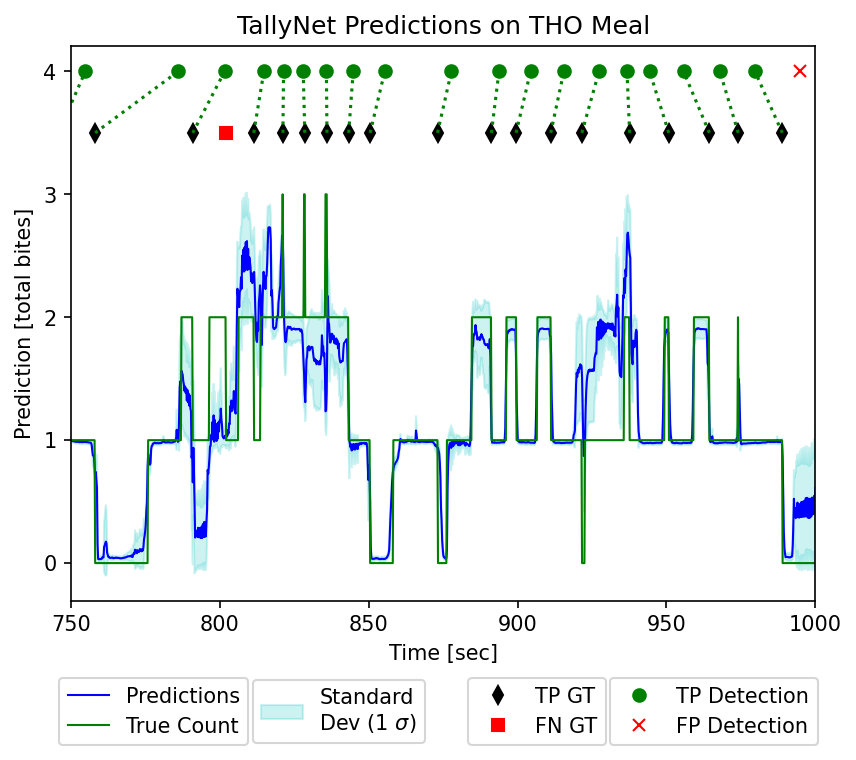

In [109]:
### GT versus Mean Prediction with Confidence Interval
### USED FOR DONG EVAL WITH Pt2Pt Matching


DETECT_HEIGHT = 4 # Height to put Detections off x-axis
GT_HEIGHT = 3.5 # Height of the GT markers in the plot 
CI_MULTIPLIER = 1 # Multiplier to use on the StdDev bars; 2 is 95% CI, 1.0 is 68% CI

x_data=AllTimesteps[0]

plt.figure('w',dpi=150)



### ESSENTIAL PLOTTING
legend_preds, = plt.plot(x_data,MeanPreds,'b',lw=1.0)

### PLOT GT Trace
legend_counts, = plt.plot(x_data,Counts,'g',lw=1.0)


### PLOT CONFIDENCE INTERVAL
ax = plt.gca()
ci_upper = MeanPreds+CI_MULTIPLIER*StdDevs # 95% CI = 2 StdDevs away for 
ci_lower = MeanPreds-CI_MULTIPLIER*StdDevs
ci_lower[ci_lower<-0.1] = -0.1 # Truncate lower limit to keep lower axis close to zero  
legend_confint = ax.fill_between(x_data, ci_lower, ci_upper, color='c', alpha=.20)



if True: # Add Detections and GT Events
	if True: # ADD GT WINDOWS
		for i in range(len(gt_times_wind)):
			x_data = [gt_times[i]]
			y_data = [GT_HEIGHT]
			
			if GT_MatchFlag[i] != -1:
				legend_MatchedGT, = plt.plot(x_data, y_data, 'kd')
			else: # if GT MatchFlag[i] == -1 and is a FN
				legend_FN, = plt.plot(x_data, y_data, 'rs')
				# plt.plot(x_data_tol, y_data, 'r-')
				# plt.plot(x_data, y_data, 'r-', linewidth = 5)
			# end of if GT_MatchFlag
		# end of for i in gt matches
	# end of ADD GT WINDOWS

	if True: # ADD DETECTIONS
		
		# DetectionHeight = numWindowLevels

		# Add True Detections
		x_data = Detections[npDetectionOutcomes==0]
		y_data = np.ones(len(x_data)) * DETECT_HEIGHT
		legend_MatchedDet, = plt.plot(x_data, y_data, 'go')

		# Add FP Detections
		x_data = Detections[npDetectionOutcomes!=0]
		y_data = np.ones(len(x_data)) * DETECT_HEIGHT
		legend_FP, = plt.plot(x_data, y_data, 'rx')
	# end of ADD DETECTIONS

	if True: # ADD CONNECTIONS BETWEEN PREDS AND DETECTIONS
		for i in range(len(gt_times_wind)):
			if GT_MatchFlag[i] != -1:
				x_data = [gt_times[i], Detections[GT_MatchFlag[i]]]
				y_data = [GT_HEIGHT, DETECT_HEIGHT]
				plt.plot(x_data, y_data, 'g:')
			# end of if GT_MatchFlag

		# end of for i in gt matches
	# End of ADD CONNECTIONS


	if False: # ADD Handedness Dot to GT WINDOWS
		for i in range(len(gt_times_wind)):
			x_data = [gt_times[i]]
			y_data = [GT_HEIGHT]

			if currBiteHand[i] == currNonDomHand:
				# plt.plot(x_data, y_data, 'g-')
				legend_NondomHand, = plt.plot(x_data, y_data, color='turquoise', marker='*')
			else: # if Dominant Hand or Both Hands
				# plt.plot(x_data, y_data, 'r-')
				legend_DomHand, = plt.plot(x_data, y_data, 'k*')
			# end of if GT_MatchFlag
		# end of for i in gt matches
	# end of ADD GT WINDOWS


# end of Add Det and GT Events

legend_FN, = plt.plot(-1, GT_HEIGHT, 'rs')

plt.yticks(np.arange(0,4.1, step=1.0))

plt.xlabel('Time [sec]')
plt.ylabel('Prediction [total bites]')


# plt.title("Predictions Across Meal OHO WS{} M{}".format(WINDOW_SIZE,currMealNum))
# PAPER TITLES
if DATABASE_FLAG == 1:
	plt.title("TallyNet Predictions on OHO Meal")
elif DATABASE_FLAG == 2:
	plt.title("TallyNet Predictions on THO Meal")
else:
	plt.title("TALLYNET PREDICITONS FOR UNKNONW DATASET")
# end of if

# plt.xlim([200, 480])
# plt.xlim([380, 580])
# plt.xlim([350, 530])
# plt.xlim([297, 480])
# plt.xlim([500,850])
plt.xlim([750, 1000])
# plt.xlim([100,100+450])
# plt.ylim([-0.05,3.25])

#ORIGINAL LEGEND FORMAT
# lgd = plt.legend([legend_preds, legend_counts, legend_confint, legend_MatchedGT, legend_FN, legend_MatchedDet, legend_FP], 
# 		   ["Predictions", "True Count", "Confidence\nInterval (1 $\sigma$)", "TP GT", "FN GT", "TP Detection", "FP Detection"],
# 		   bbox_to_anchor=(1.05, 0.5), loc='center left'
# 		   # loc='outside lower center'
# 		  )

LEGEND_HEIGHT = -0.2
lgd_1 = plt.legend([legend_preds, legend_counts], 
		   ["Predictions", "True Count"],
		   bbox_to_anchor=(-0.03, LEGEND_HEIGHT), loc='center left'
		   # loc='outside lower center'
		  )
ax.add_artist(lgd_1)
lgd_2 = plt.legend([legend_confint], 
		   ["Standard\nDev (1 $\sigma$)"],
		   bbox_to_anchor=(.23, LEGEND_HEIGHT), loc='center left'
		   # loc='outside lower center'
		  )
ax.add_artist(lgd_2)
lgd_3 = plt.legend([legend_MatchedGT, legend_FN], 
		   ["TP GT", "FN GT", ],
		   bbox_to_anchor=(0.52, LEGEND_HEIGHT), loc='center left'
		   # loc='outside lower center'
		  )
ax.add_artist(lgd_3)
lgd_4 = plt.legend([legend_MatchedDet, legend_FP], 
		   ["TP Detection", "FP Detection"],
		   bbox_to_anchor=(0.71, LEGEND_HEIGHT), loc='center left'
		   # loc='outside lower center'
		  )

# plt.savefig('W40_PredvsGT_OHO_M{}.png'.format(currMealNum))
# plt.savefig('AllPreds_OneMeal_M{}.png'.format(SingleMealSelect[currMealNum]))
# plt.savefig('z_Visualizations/MeanPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))

#PAper versions used 15 sec A1333 for all three datasets, with hand picked meals and times to show TP, FN, and FP instance
# plt.savefig('PAPER_ConfInt_OHO_M{}_v1-2.pdf'.format(currMealNum), bbox_extra_artists=(lgd_4,), bbox_inches='tight') # Used meal 43, range [420 sec, 600 sec]
# plt.savefig('PAPER_ConfInt_Clem_M{}.pdf'.format(currMealNum)) # Used meal 43, range [420 sec, 600 sec]



plt.savefig('Figures/Timeline_PredVsGT_THO_CGv3_M{}_v1.pdf'.format(currMealNum), bbox_extra_artists=(lgd_4,), bbox_inches='tight') # Used meal 43, range [420 sec, 600 sec]


# plt.close()

print("Finished with Saving Plots.")

/local_scratch/slurm.13452111/ipykernel_671525/3008421574.py:19: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  f.subplots_adjust(left=0.30)


Finished with Saving Plots.


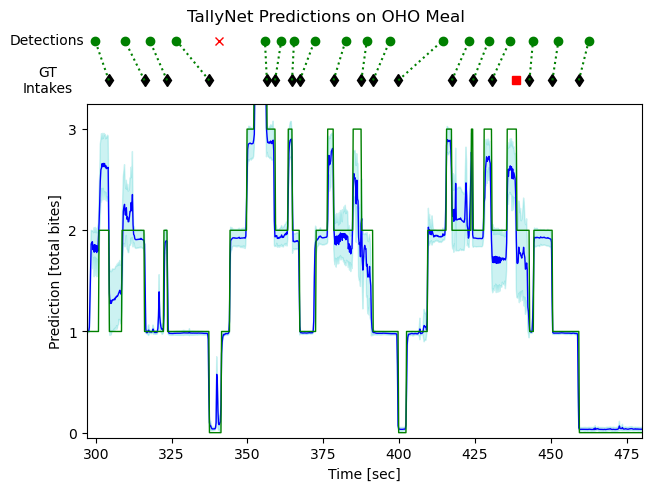

<Figure size 1280x960 with 0 Axes>

In [51]:
########## MODIFICATION TO USE SUBPLOTS AND MOVE DETECTIONS/GT PAIRS OFF THE "PREDICTIONS" Y-AXIS ##########

### GT versus Mean Prediction with Confidence Interval
### USED FOR DONG EVAL WITH Pt2Pt Matching

DETECT_HEIGHT = 4 # Height to put Detections off x-axis
GT_HEIGHT = 3.5 # Height of the GT markers in the plot 
CI_MULTIPLIER = 1 # Multiplier to use on the StdDev bars; 2 is 95% CI, 1.0 is 68% CI

StartTime = 297
Duration = 183

x_data=AllTimesteps[0]


f, (a1, a0) = plt.subplots(2, 1, height_ratios=[1,6], layout='constrained')
# f, (a1, a0) = plt.subplots(2, 1, height_ratios=[1,6])
plt.figure('w',dpi=200)
f.subplots_adjust(left=0.30)
### ESSENTIAL PLOTTING
legend_preds, = a0.plot(x_data,MeanPreds,'b',lw=1.0)

### PLOT GT Trace
legend_counts, = a0.plot(x_data,Counts,'g',lw=1.0)


### PLOT CONFIDENCE INTERVAL
# ax = plt.gca(a0)
ci_upper = MeanPreds+CI_MULTIPLIER*StdDevs # 95% CI = 2 StdDevs away for 
ci_lower = MeanPreds-CI_MULTIPLIER*StdDevs
ci_lower[ci_lower<-0.1] = -0.1 # Truncate lower limit to keep lower axis close to zero  
legend_confint = a0.fill_between(x_data, ci_lower, ci_upper, color='c', alpha=.20)


if True: # Add Detections and GT Events
	if True: # ADD GT WINDOWS
		for i in range(len(gt_times_wind)):
			x_data = [gt_times[i]]
			y_data = [GT_HEIGHT]

			if GT_MatchFlag[i] != -1:
				legend_MatchedGT, = a1.plot(x_data, y_data, 'kd')
			else: # if GT MatchFlag[i] == -1 and is a FN
				legend_FN, = a1.plot(x_data, y_data, 'rs')
				# plt.plot(x_data_tol, y_data, 'r-')
				# plt.plot(x_data, y_data, 'r-', linewidth = 5)
			# end of if GT_MatchFlag
		# end of for i in gt matches
	# end of ADD GT WINDOWS

	if True: # ADD DETECTIONS
		# Add True Detections
		x_data = Detections[np.logical_and(npDetectionOutcomes==0, Detections>StartTime)] # CROP ITEM FOR PAPER FIGURE
		# x_data = Detections[npDetectionOutcomes==0] # ORIGINAL
		y_data = np.ones(len(x_data)) * DETECT_HEIGHT
		legend_MatchedDet, = a1.plot(x_data, y_data, 'go')

		# Add FP Detections
		x_data = Detections[npDetectionOutcomes!=0]
		y_data = np.ones(len(x_data)) * DETECT_HEIGHT
		legend_FP, = a1.plot(x_data, y_data, 'rx')
	# end of ADD DETECTIONS

	if True: # ADD CONNECTIONS BETWEEN PREDS AND DETECTIONS
		for i in range(len(gt_times_wind)):
			if GT_MatchFlag[i] != -1:
				if (gt_times[i] < StartTime-10):
					continue
				# end of for cropping in paper Figure
				x_data = [gt_times[i], Detections[GT_MatchFlag[i]]]
				y_data = [GT_HEIGHT, DETECT_HEIGHT]
				a1.plot(x_data, y_data, 'g:')
			# end of if GT_MatchFlag

		# end of for i in gt matches
	# End of ADD CONNECTIONS

	if False: # ADD Handedness Dot to GT WINDOWS
		for i in range(len(gt_times_wind)):
			x_data = [gt_times[i]]
			y_data = [GT_HEIGHT]

			if currBiteHand[i] == currNonDomHand:
				# plt.plot(x_data, y_data, 'g-')
				legend_NondomHand, = a1.plot(x_data, y_data, color='turquoise', marker='*')
			else: # if Dominant Hand or Both Hands
				# plt.plot(x_data, y_data, 'r-')
				legend_DomHand, = a1.plot(x_data, y_data, 'k*')
			# end of if GT_MatchFlag
		# end of for i in gt matches
	# end of ADD GT WINDOWS

# end of Add Det and GT Events


a0.set_yticks(np.arange(0,4.1, step=1.0))

a0.set_xlabel('Time [sec]')
a0.set_ylabel('Prediction [total bites]')

a1.axis("off")
# plt.title("Predictions Across Meal OHO WS{} M{}".format(WINDOW_SIZE,currMealNum))
# PAPER TITLES
# plt.title("TallyNet Predictions on THO Meal")
f.suptitle("TallyNet Predictions on OHO Meal")



# plt.xlim([200, 400])
# plt.xlim([420, 600])
# plt.xlim([350, 530])
# plt.xlim([520,560])
a0.set_xlim([StartTime,StartTime+Duration])
a1.set_xlim([StartTime,StartTime+Duration])
a0.set_ylim([-0.05,3.25])

# Markers need some extra space for frame to not crop
MarkerExtraSpace = 0.1
a1.set_ylim([GT_HEIGHT - MarkerExtraSpace, DETECT_HEIGHT + MarkerExtraSpace])

# lgd = plt.legend([legend_preds, legend_counts, legend_confint, legend_MatchedGT, legend_FN, legend_MatchedDet, legend_FP], 
# 		   ["Predictions", "True Count", "Confidence Interval (1 $\sigma$)", "TP GT", "TP Detection", "FN GT", "FP Detection"],
# 		   bbox_to_anchor=(1.05, 0.5), loc='center left'
# 		   # loc='outside lower center'
# 		  )


a1.set_frame_on(False)

a1.text(StartTime-13, GT_HEIGHT, "GT\nIntakes", va='center', ha='center', multialignment='center')
a1.text(StartTime-13, DETECT_HEIGHT, "Detections", va='center', ha='center', multialignment='center')


# plt.savefig('W40_PredvsGT_OHO_M{}.png'.format(currMealNum))
# plt.savefig('AllPreds_OneMeal_M{}.png'.format(SingleMealSelect[currMealNum]))
# plt.savefig('z_Visualizations/MeanPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))

#PAper versions used 15 sec A1333 for all three datasets, with hand picked meals and times to show TP, FN, and FP instance
plt.savefig('Figures/Timeline_Separate_THO_CGv3_M{}_v1.pdf'.format(currMealNum)) # Used meal 43, range [420 sec, 600 sec]
# plt.savefig('PAPER_ConfInt_OHO_M{}.pdf'.format(currMealNum), bbox_extra_artists=(lgd,), bbox_inches='tight') # Used meal 43, range [420 sec, 600 sec]
# plt.savefig('PAPER_ConfInt_OHO_M{}_v2.pdf'.format(currMealNum), bbox_inches='tight') # Used meal 43, range [420 sec, 600 sec]
# plt.savefig('PAPER_ConfInt_Clem_M{}.pdf'.format(currMealNum)) # Used meal 43, range [420 sec, 600 sec]



# plt.close()

print("Finished with Saving Plots.")

In [ ]:
### GT versus Mean Prediction with Confidence Interval
### USED FOR KYRITSIS EVAL WITH GT TOLERANCE

CI_MULTIPLIER = 1 # Multiplier to use on the StdDev bars; 2 is 95% CI, 1.0 is 65% CI
BEFORE_TOL = 8 # Tolerance used in GT Window Before the gesture 
AFTER_TOL = 8 # Tolerance used in GT Window After the gesture
DETECT_HEIGHT = 4 # Height to put GT and Detections off x-axis


x_data=AllTimesteps[0]

plt.figure('w',dpi=200)

plt.plot(x_data,MeanPreds,'b',lw=0.5)

### PLOT GT Trace
plt.plot(x_data,Counts,'g',lw=0.5)

### PLOT CONFIDENCE INTERVAL
ax = plt.gca()
ci_upper = MeanPreds+CI_MULTIPLIER*StdDevs # 95% CI = 2 StdDevs away for 
ci_lower = MeanPreds-CI_MULTIPLIER*StdDevs
ci_lower[ci_lower<-0.1] = -0.1 # Truncate lower limit to keep lower axis close to zero  
ax.fill_between(x_data, ci_lower, ci_upper, color='c', alpha=.15)


if True: # Add Detections and GT Events
	if True: # ADD GT WINDOWS
		cntr = 1
		numWindowLevels = 4
		for i in range(len(gt_times_wind)):
			x_data_tol = [gt_times_wind[i,0]-BEFORE_TOL, gt_times_wind[i,1]+AFTER_TOL]
			x_data = [gt_times_wind[i,0], gt_times_wind[i,1]]
			y_data = [GT_HEIGHT+cntr/4, GT_HEIGHT+cntr/4]

			if GT_MatchFlag[i] != -1:
				# plt.plot(x_data, y_data, 'g-')
				plt.plot(x_data_tol, y_data, 'g-')
				plt.plot(x_data, y_data, 'g-', linewidth = 5)
			else: # if GT MatchFlag[i] == -1 and is a FN
				# plt.plot(x_data, y_data, 'r-')
				plt.plot(x_data_tol, y_data, 'r-')
				plt.plot(x_data, y_data, 'r-', linewidth = 5)
			# end of if GT_MatchFlag

			cntr = (cntr%numWindowLevels)+1
		# end of for i in gt matches
	# end of ADD GT WINDOWS

	if True: # ADD DETECTIONS
		DetectionHeight = DETECT_HEIGHT + DETECT_AND_GT_OFFSET
		# DetectionHeight = numWindowLevels

		# Add True Detections
		x_data = Detections[npDetectionOutcomes==0]
		y_data = np.ones(len(x_data)) * DetectionHeight
		plt.plot(x_data, y_data, 'bd')

		# Add FP Detections
		x_data = Detections[npDetectionOutcomes!=0]
		y_data = np.ones(len(x_data)) * DetectionHeight
		plt.plot(x_data, y_data, 'rd')
	# end of ADD DETECTIONS

	if True: # ADD CONNECTIONS BETWEEN PREDS AND DETECTIONS
		cntr = 1
		numWindowLevels = 4
		for i in range(len(gt_times_wind)):
			if GT_MatchFlag[i] != -1:
				x_data = [(gt_times_wind[i,0]+gt_times_wind[i,1])/2, Detections[GT_MatchFlag[i]]]
				y_data = [GT_HEIGHT + cntr/4, DETECT_HEIGHT]
				plt.plot(x_data, y_data, 'g:')
			# end of if GT_MatchFlag

			cntr = (cntr%numWindowLevels)+1
		# end of for i in gt matches
	# End of ADD CONNECTIONS


	if False: # ADD Handedness Dot to GT WINDOWS
		cntr = 1
		numWindowLevels = 4
		for i in range(len(gt_times_wind)):
			x_data_tol = [gt_times_wind[i,0]-BEFORE_TOL, gt_times_wind[i,1]+AFTER_TOL]
			x_data = [(gt_times_wind[i,0]+gt_times_wind[i,1])/2]
			y_data = [GT_HEIGHT+cntr/4]

			if currBiteHand[i] == currNonDomHand:
				# plt.plot(x_data, y_data, 'g-')
				plt.plot(x_data, y_data, color='turquoise', marker='*')
			else: # if Dominant Hand or Both Hands
				# plt.plot(x_data, y_data, 'r-')
				plt.plot(x_data, y_data, 'k*')
			# end of if GT_MatchFlag

			cntr = (cntr%numWindowLevels)+1
		# end of for i in gt matches
	# end of ADD GT WINDOWS

	# # Start Plotting GT
	# GT_BaselineY = 2.5
	# staggerFlag=0
	# for i in range(len(gt_times)):
	# 	if staggerFlag == 0:
	# 		plt.plot([gt_times[i],gt_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
	# 	elif staggerFlag == 1:
	# 		plt.plot([gt_times[i],gt_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
	# 	staggerFlag = (staggerFlag+1)%2
	# # End of plotting GT
	
# end of Add Det and GT Events

plt.yticks(np.arange(0,4.1, step=1.0))

plt.xlabel('Time [sec]')
plt.ylabel('Prediction [total bites]')

plt.title("Predictions Across Meal OHO WS{} M{}".format(WINDOW_SIZE,currMealNum))

plt.xlim([200, 400])

# plt.savefig('W40_PredvsGT_OHO_M{}.png'.format(currMealNum))
# plt.savefig('AllPreds_OneMeal_M{}.png'.format(SingleMealSelect[currMealNum]))
# plt.savefig('z_Visualizations/MeanPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))
# plt.close()

print("Finished with Saving Plots.")

In [ ]:
len(npDetectionOutcomes==0)
print(len(Detections))


In [ ]:
np.array(Detections)[npDetectionOutcomes==0]

In [ ]:
Detections

In [ ]:
All_Timesteps=[]
All_gt_bite_times = []
for currEvalIndex in SingleMealSelect:
	currMealNum,features_input,timestep_ref,gt_bite_times = compiled_eval_data[currEvalIndex]
	All_Timesteps.append(timestep_ref)
	All_gt_bite_times.append(gt_bite_times)
# end of currEvalIndex loop

print("Finished creating timestep arrays...")

In [ ]:
### TOGGLE PLOT COMMANDS TO DETERMINE WHICH MODELS LEARN WELL AND WHICH DON'T

for currMealNum in range(len(SingleMealSelect)):
# for currMealNum in [2]:
	AllPreds = All_AllPreds[currMealNum]
	x_data=All_Timesteps[currMealNum]
	gt_bite_times = All_gt_bite_times[currMealNum]
	GT_Targets = np.ones(np.shape(AllGtTargets[currMealNum]))*(-1)
	for i in range(len(GT_Targets)):
		GT_Targets[i] = AllGtTargets[currMealNum][i]
	# End of copying targets without python making an alias

	AvgPreds = np.ones(len(AllPreds[0]))*(-1)
	for target_idx in range(len(GT_Targets)):
		# scale the GT bites by scale factor
		GT_Targets[target_idx] = SCALE_FACTOR * GT_Targets[target_idx]
		
		Avg_sum=0
		#Compute average predictions
		for i in range(len(AllPreds)):
			Avg_sum+=AllPreds[i][target_idx]
		AvgPreds[target_idx] = Avg_sum/len(AllPreds)
	# end of for target_idx
	
	plt.figure('w',dpi=300)

	# 10 sec fold 1 --> Good = 3, 6, 8; Weird = 5; Bad = 0, 1, 2, 4, 7, 9
	# 10 sec fold 3 --> Good = 0, 1, 3, 5, 7, 8, 9; Weird = 4; Bad = 2, 6

	# plt.plot(x_data,AllPreds[0],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[1],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[2],'c',lw=0.5)
	# plt.plot(x_data,AllPreds[3],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[4],'k',lw=0.5)
	# plt.plot(x_data,AllPreds[5],'b',lw=0.5)
	
	
	plt.plot(x_data,AvgPreds,'b',lw=0.5)
	
	
	# Start Plotting GT
	GT_BaselineY = 2.5
	staggerFlag=0
	for i in range(len(gt_bite_times)):
		if staggerFlag == 0:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
		elif staggerFlag == 1:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
		staggerFlag = (staggerFlag+1)%2
	# End of plotting GT
	
	
	plt.plot(x_data,GT_Targets,'g',lw=0.5)
	
	
	
	plt.xlabel('Time [sec]')
	plt.ylabel('Prediction [total bites]')

	plt.title("Predictions Across Meal {} F{} M{}".format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))

	# plt.savefig('AllPreds_OneMeal_M{}.png'.format(SingleMealSelect[currMealNum]))
	# plt.savefig('z_Visualizations/AvgPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))
	# plt.close()
# end of for meal loop
print("Finished with Saving Plots.")

In [ ]:
### TOGGLE PLOT COMMANDS TO DETERMINE WHICH MODELS LEARN WELL AND WHICH DON'T

for currMealNum in range(len(SingleMealSelect)):
# for currMealNum in [2]:
	AllPreds = All_AllPreds[currMealNum]
	x_data=All_Timesteps[currMealNum]
	gt_bite_times = All_gt_bite_times[currMealNum]
	
	plt.figure('w',dpi=300)

	# 10 sec fold 1 --> Good = 3, 6, 8; Weird = 5; Bad = 0, 1, 2, 4, 7, 9
	# 10 sec fold 3 --> Good = 0, 1, 3, 5, 7, 8, 9; Weird = 4; Bad = 2, 6

	plt.plot(x_data,AllPreds[0],'b',lw=0.5)
	plt.plot(x_data,AllPreds[1],'b',lw=0.5)
	plt.plot(x_data,AllPreds[2],'c',lw=0.5)
	plt.plot(x_data,AllPreds[3],'b',lw=0.5)
	plt.plot(x_data,AllPreds[4],'k',lw=0.5)
	plt.plot(x_data,AllPreds[5],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[6],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[7],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[8],'r',lw=0.5)
	# plt.plot(x_data,AllPreds[9],'b',lw=0.5)

	
	
	GT_Targets = np.ones(np.shape(AllGtTargets[currMealNum]))*(-1)
	for i in range(len(GT_Targets)):
		GT_Targets[i] = AllGtTargets[currMealNum][i]
	# End of copying targets without python making an alias
	for target_idx in range(len(GT_Targets)):
		# scale the GT bites by scale factor
		GT_Targets[target_idx] = SCALE_FACTOR * GT_Targets[target_idx]
	# end of for target_idx
	plt.plot(x_data,GT_Targets,'g',lw=0.5)

	
	
	# Start Plotting GT
	GT_BaselineY = 2.5
	staggerFlag=0
	for i in range(len(gt_bite_times)):
		if staggerFlag == 0:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
		elif staggerFlag == 1:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
		staggerFlag = (staggerFlag+1)%2
	# End of plotting GT
	
	# Start Plotting GT
	GT_BaselineY = 2.5
	staggerFlag=0
	for i in range(len(gt_bite_times)):
		if staggerFlag == 0:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
		elif staggerFlag == 1:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
		staggerFlag = (staggerFlag+1)%2
	# End of plotting GT

	plt.xlabel('Time [sec]')
	plt.ylabel('Prediction [total bites]')

	plt.title("Predictions Across Meal {} F{} M{}".format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))

	# plt.savefig('z_Visualizations/AllPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))
	# plt.close()
# end of for meal loop
print("Finished with Saving Plots.")